In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("/Volumes/workspace/default/netflix_analysis/netflix_eda.csv")


# Step 3: View top 5 rows
print(df.head())

# Step 4: Basic info
df.info()


  show_id     type  ... num_seasons rating_group
0      s1    Movie  ...         NaN         Teen
1      s2  TV Show  ...         2.0        Adult
2      s3  TV Show  ...         1.0        Adult
3      s4  TV Show  ...         1.0        Adult
4      s5  TV Show  ...         2.0        Adult

[5 rows x 15 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       8807 non-null   object 
 1   type          8807 non-null   object 
 2   title         8807 non-null   object 
 3   director      8807 non-null   object 
 4   cast          7982 non-null   object 
 5   country       8807 non-null   object 
 6   date_added    8797 non-null   object 
 7   release_year  8807 non-null   int64  
 8   rating        8807 non-null   object 
 9   duration      8804 non-null   object 
 10  listed_in     8807 non-null   object 
 11  description 

In [0]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,directory,num_seasons,rating_group
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",kirsten johnson,NaN,Teen
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",NaN,2.0,Adult
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,julien leclercq,1.0,Adult
3,s4,TV Show,Jailbirds New Orleans,Unknown,NaN,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",NaN,1.0,Adult
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,NaN,2.0,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",david fincher,NaN,Adult
8803,s8804,TV Show,Zombie Dumb,Unknown,NaN,Unknown,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",NaN,2.0,Kids
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,ruben fleischer,NaN,Adult
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",peter hewitt,NaN,Other


In [0]:

# Check first few rows and column names
print(df_read.head())
print("\nColumns:\n", df_read.columns)


  show_id     type  ... num_seasons rating_group
0      s1    Movie  ...         NaN         Teen
1      s2  TV Show  ...         2.0        Adult
2      s3  TV Show  ...         1.0        Adult
3      s4  TV Show  ...         1.0        Adult
4      s5  TV Show  ...         2.0        Adult

[5 rows x 15 columns]

Columns:
 Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'directory', 'num_seasons', 'rating_group'],
      dtype='object')


clustering


In [0]:
# Step 1️⃣: Import Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.cluster import KMeans

# Step 2️⃣: Load Dataset
df = pd.read_csv("/Volumes/workspace/default/netflix_analysis/netflix_eda.csv")

# Step 3️⃣: Prepare genre features
mlb = MultiLabelBinarizer()
genres = df_read['listed_in'].astype(str).str.split(', ')
genre_features = mlb.fit_transform(genres)

# Step 4️⃣: Prepare duration feature
def extract_duration(row):
    if row['type'] == 'Movie':
        try:
            return int(str(row['duration']).split(' ')[0])  # e.g., "90 min"
        except:
            return 0
    elif row['type'] == 'TV Show':
        try:
            # Approximation: 1 season ≈ 60 min
            return int(str(row['duration']).split(' ')[0]) * 60
        except:
            return 0
    else:
        return 0

duration_feature = df_read.apply(extract_duration, axis=1).values.reshape(-1, 1)

# Step 5️⃣: Prepare rating feature (convert text to numeric)
rating_map = {k: v for v, k in enumerate(df_read['rating_group'].dropna().unique())}
rating_feature = df_read['rating_group'].map(rating_map).fillna(0).values.reshape(-1, 1)

# Step 6️⃣: Combine all features
X = np.hstack([genre_features, duration_feature, rating_feature])

# Step 7️⃣: Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 8️⃣: Apply K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_read['cluster'] = kmeans.fit_predict(X_scaled)

# Step 9️⃣: Create combined table with cluster counts
cluster_counts = df_read['cluster'].value_counts().reset_index()
cluster_counts.columns = ['cluster', 'cluster_count']

final_table = df_read[['title', 'listed_in', 'duration', 'rating_group', 'cluster']].merge(
    cluster_counts, on='cluster', how='left'
)

# Step 🔟: Display results neatly
print("\n📊 Final Clustered Table:\n")
display(final_table.head(20))

# Step 11️⃣: Optionally, check total clusters summary
print("\n📈 Cluster Counts:\n")
display(cluster_counts)



📊 Final Clustered Table:



title,listed_in,duration,rating_group,cluster,cluster_count
Dick Johnson Is Dead,Documentaries,90 min,Teen,2,872
Blood & Water,"International TV Shows, TV Dramas, TV Mysteries",2 Seasons,Adult,1,1426
Ganglands,"Crime TV Shows, International TV Shows, TV Action & Adventure",1 Season,Adult,0,212
Jailbirds New Orleans,"Docuseries, Reality TV",1 Season,Adult,4,2029
Kota Factory,"International TV Shows, Romantic TV Shows, TV Comedies",2 Seasons,Adult,1,1426
Midnight Mass,"TV Dramas, TV Horror, TV Mysteries",1 Season,Adult,1,1426
My Little Pony: A New Generation,Children & Family Movies,91 min,Other,4,2029
Sankofa,"Dramas, Independent Movies, International Movies",125 min,Adult,3,4268
The Great British Baking Show,"British TV Shows, Reality TV",9 Seasons,Teen,4,2029
The Starling,"Comedies, Dramas",104 min,Teen,3,4268



📈 Cluster Counts:



cluster,cluster_count
3,4268
4,2029
1,1426
2,872
0,212


In [0]:
df_read.groupby('cluster')['listed_in'].apply(lambda x: ', '.join(x.head(5)))


cluster
0    Crime TV Shows, International TV Shows, TV Act...
1    International TV Shows, TV Dramas, TV Mysterie...
2    Documentaries, Documentaries, International Mo...
3    Dramas, Independent Movies, International Movi...
4    Docuseries, Reality TV, Children & Family Movi...
Name: listed_in, dtype: object

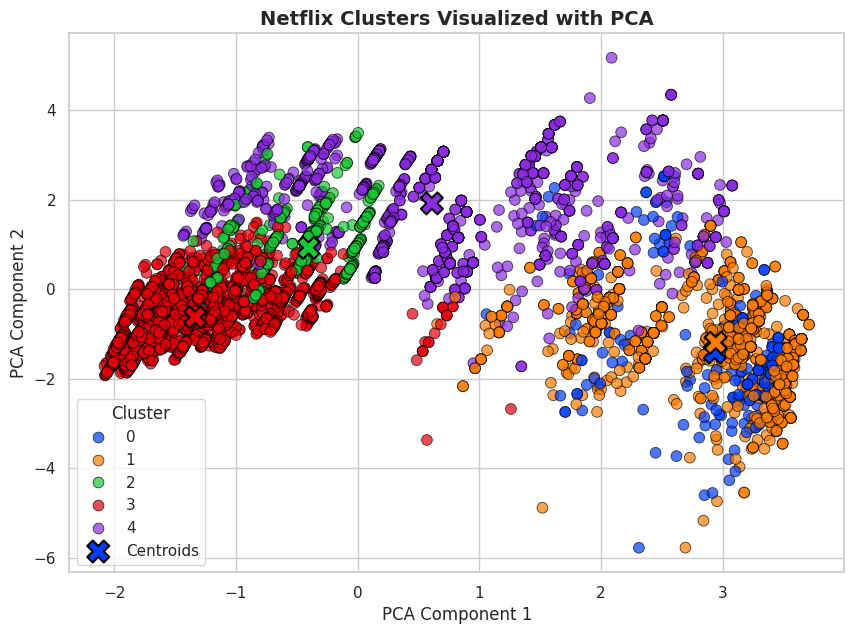

In [0]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1️⃣: Reduce features to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 2️⃣: Add PCA results to your DataFrame
df_read['PCA1'] = X_pca[:, 0]
df_read['PCA2'] = X_pca[:, 1]

# Step 3️⃣: Plot clusters
plt.figure(figsize=(10, 7))
sns.set(style="whitegrid")

# Use bright, distinct colors for each cluster
palette = sns.color_palette("bright", len(df_read['cluster'].unique()))

sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='cluster',
    palette=palette,
    data=df_read,
    alpha=0.7,
    s=60,
    edgecolor='black'
)

# Step 4️⃣: Plot cluster centroids in distinct colors
centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centers[:, 0], centers[:, 1],
    c=palette,
    s=250,
    marker='X',
    edgecolors='black',
    linewidths=1.5,
    label='Centroids'
)

# Step 5️⃣: Finishing touches
plt.title('Netflix Clusters Visualized with PCA', fontsize=14, fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster', loc='best')
plt.show()


classification


In [0]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [0]:
df_features = df_read.copy()

In [0]:
# Convert duration text to numbers
df_features['duration'] = (
    df_features['duration'].str.extract(r'(\d+)').astype(float).fillna(0)
)


In [0]:
if 'content_age_years' in df_features.columns:
    df_features['content_age_years'] = df_features['content_age_years'].fillna(0)
else:
    df_features['content_age_years'] = 0  # fallback


In [0]:
# Take the first genre (primary)
df_read['primary_genre'] = df_read['listed_in'].astype(str).str.split(',').str[0].str.strip()

# Encode 'primary_genre' and 'rating_group' as numeric categories
df_read['primary_genre_code'] = df_read['primary_genre'].astype('category').cat.codes
df_read['rating_group_code'] = df_read['rating_group'].astype('category').cat.codes

# View the results
print(df_read[['title', 'primary_genre', 'primary_genre_code', 'rating_group', 'rating_group_code']].head(10))


                              title  ... rating_group_code
0              Dick Johnson Is Dead  ...                 3
1                     Blood & Water  ...                 0
2                         Ganglands  ...                 0
3             Jailbirds New Orleans  ...                 0
4                      Kota Factory  ...                 0
5                     Midnight Mass  ...                 0
6  My Little Pony: A New Generation  ...                 2
7                           Sankofa  ...                 0
8     The Great British Baking Show  ...                 3
9                      The Starling  ...                 3

[10 rows x 5 columns]


In [0]:

from datetime import datetime
# 1️⃣ Create primary genre from 'listed_in'
df_features['primary_genre'] = df_features['listed_in'].astype(str).str.split(',').str[0].str.strip()

# 2️⃣ Calculate 'content_age_years' (how old the show/movie is)
current_year = datetime.now().year
df_features['content_age_years'] = current_year - df_features['release_year']

# 3️⃣ Encode categorical columns
df_features['rating_group'] = df_features['rating_group'].astype('category').cat.codes
df_features['primary_genre'] = df_features['primary_genre'].astype('category').cat.codes

# 4️⃣ Select feature columns
feature_cols = ['duration', 'rating_group', 'content_age_years', 'primary_genre']
X = df_features[feature_cols]

# 5️⃣ Encode target variable (Movie = 0, TV Show = 1)
y = df_features['type'].map({'Movie': 0, 'TV Show': 1})

# 6️⃣ Preview data
print(X.head())
print("\nTarget (y):\n", y.head())

   duration  rating_group  content_age_years  primary_genre
0      90.0             3                  5             10
1       2.0             0                  4             16
2       1.0             0                  4              8
3       1.0             0                  4             11
4       2.0             0                  4             16

Target (y):
 0    0
1    1
2    1
3    1
4    1
Name: type, dtype: int64


In [0]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [0]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [0]:
y_pred = clf.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1214
           1       1.00      1.00      1.00       548

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762

Accuracy: 1.0


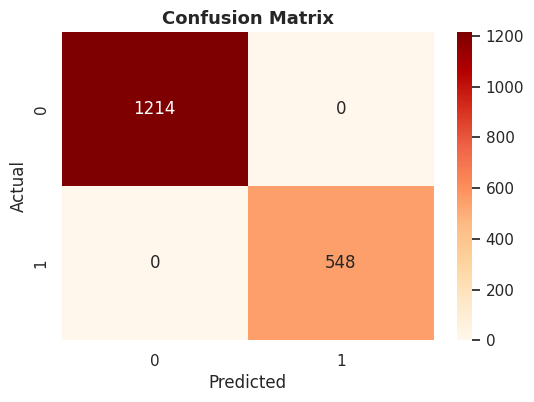

In [0]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='OrRd')  # 🔶 orange-red palette
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


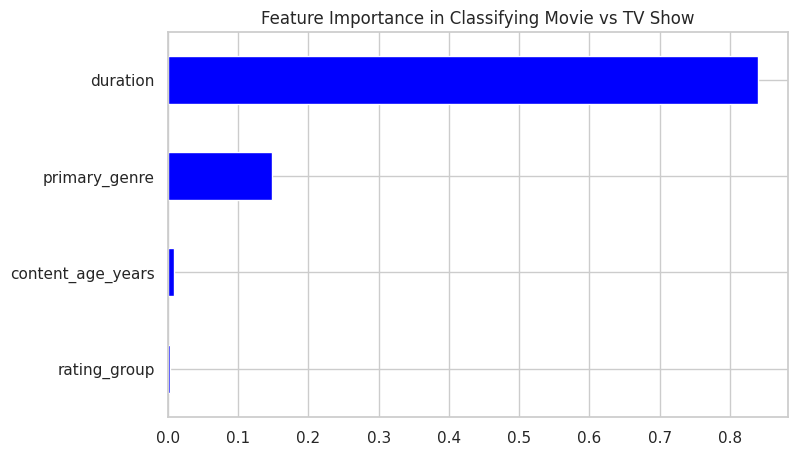

In [0]:
# Check Feature Importance (Which Features Matter Most?)
importances = pd.Series(clf.feature_importances_, index=feature_cols)
importances.sort_values().plot(kind='barh', figsize=(8,5), color='blue')
plt.title('Feature Importance in Classifying Movie vs TV Show')
plt.show()
